In [1]:
import torch
from sorl.gat_sim import GAT, GATConfig, BOS_TOKEN_ID
torch.set_float32_matmul_precision('high')  # Enable TF32 for ~2x speedup
# For fast training, set 'BOS_TOKEN_ID' to 15 in 'sorl/gat_sim.py' 

gat_config = GATConfig(
    vocab_sizes=[BOS_TOKEN_ID+1, 6],  # 6 abstract tokens
    n_layer=4,
    n_head=4,
    n_embd=128,
    device="cuda" if torch.cuda.is_available() else "cpu",
    flex_kernel_options={
            "BLOCK_M": 32, "BLOCK_N": 32,
            "BLOCK_M1": 32, "BLOCK_N1": 64, "BLOCK_M2": 64, "BLOCK_N2": 32
        }
)
    
model = GAT(gat_config)
# model = model.to("cuda")
# model = torch.compile(model)

In [2]:
# ---- Copy & Paste Data Loader ----
from data.copy_paste import CopyPasteDataLoader

seq_len = 4
loader = CopyPasteDataLoader(vocab_size=16, max_token=10, seq_len=seq_len, device='cpu')
tokens, loss_mask = loader.get_batch(2)

$\textbf{Experiment}$ 1.
- temperature=1.0, seq_len=1, memory_span=4 | acc: 100% | traj loss: 0.02 | abs loss: 0.01 | search adv: 90% | # abs utilized: 1 | utilized rate: 16%
- temperature=1.0, seq_len=1, memory_span=1 | acc: 100% | traj loss: 0.02 | abs loss: 0.01 | search adv: 90% | # abs utilized: 1 | utilized rate: 16%
- temperature=5.0, seq_len=1, memory span=1 | acc: 100% | traj loss: 0.01 | abs loss: 0.01 | search adv: 90% | # abs utilized: 3 | utilized rate: 50% 
- temperature=10.0, seq_len=1, memory span=1 | acc: 100% | traj loss: 0.02 | abs loss: 0.01 | search adv: 90% | # abs utilized: 2 | utilized rate: 33% 
- temperature=10.0, seq_len=1, memory span=1 | acc: 100% | traj loss: 0.01 | abs loss: 0.01 | search adv: 90% | # abs utilized: 4 | utilized rate: 67% 

- temperature=10.0 seq_len=4 memory_span=10 K=1 | acc: 100% | traj loss: 0.82 | abs loss: 0.01 | search adv: 80% | # abs utilized: 1 | utilized rate: 16% 
- temperature=10.0 seq_len 4 memory_span 10 K 4 | acc: 0% | traj loss: 1.86 | abs loss 0.26 | search adv: 5.42% | # abs utilized: 3 | utilized rate: 33%
- temperature=10.0 seq len 4 memory span 10 K 2 | acc: 0% | traj loss: 1.81 | abs loss 0.02 | search adv: 23% | # abs utilized: 1 | utilized rate: 16% 
- temperature=5.0 seq len 4 memory span 10 K 2 | acc: 0% | traj loss: 1.78 | abs loss 0.02 | search adv: 47% | # abs utilized: 1 | utilized rate: 16% 
- temperature=5.0 seq len 4 memory span 1 K 2 | acc: 0% | traj loss: 1.82 | abs loss: 0.02 | search adv: 43% | # abs utilized: 1 | utilized rate: 16%

- (GPT) (BTW it's equivalent to using SoRL with $K = \infty$) seq len 4 memory span 1 | traj loss: 1.82
- (GPT) (BTW it's equivalent to using SoRL with $K = \infty$) seq len 4 memory span 10 | traj loss: 0.84 | acc: 100%


$\textbf{Analysis 1}$. A failure mode here, is the model would repeatitively predict the same number no matter what. I do wonder how is it possible that we are able to get 'advantage' despite having 0 accuracy here? Also what about the baseline performance in this case? Can a naive transformer nails copy & paste? 



$\textbf{Reflection 1}$. 
- This is starting to make sense, with greedy rollout retained, using a high temperature is actually just brodening the horizon, it's actually more beneficial than a low temperature rollout, as later is very similar to greedy rollout and therefore risks collapsing the vocabulary. So, higher temperature helps increase the vocabulary utilization rate. But intuitively, it feels like there should be an 'optimal utilization rate' of sorts --- yet trajectory perplexity should surely be the most important target here. 



In [4]:
from sorl.neo_utils import sorl_search, sorl_search_v2, compute_loss, sorl_evaluate

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.1)
batch_size = 16
# memory_span = 1
memory_span = 2 * seq_len + 2
attn_blocksize = 1792
K = 9999
n = 4
# assert seq_len % K == 0, f"seq_len {seq_len} must be divisible by K {K}"
max_iterations = 1
temperature = 5.0
num_steps = 200

for step in range(num_steps): 
    # memory_span = seq_len + int((1 - step / num_steps) * (seq_len + 2))
    # print(f"step {step} | memory_span: {memory_span}")
 
    optimizer.zero_grad()

    tokens, _ = loader.get_batch(batch_size)

    # --- mixture of SoRL selection & deep supervision (avg. loss per iteration) ---
    with torch.no_grad(): 
        search_tokens, search_ppt, search_adv = sorl_search(tokens, model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperature,
                                                               truncate_seq_len=False)
    
    # --- compute loss ---
    traj_loss, abs_loss = compute_loss(search_tokens, model, memory_span=memory_span, attn_blocksize=attn_blocksize)
    loss = traj_loss + abs_loss


    # GAPT
    
    # --- optimize --- 
    loss.backward() 
    optimizer.step()

    if step % 2 == 0: 
        with torch.no_grad(): 
            val_tokens, val_adv, traj_loss, abs_loss = sorl_evaluate(tokens, model, n=4, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=10.0,
                                                                   truncate_seq_len=False)
            traj_loss, abs_loss = compute_loss(tokens, model, memory_span=memory_span, attn_blocksize=attn_blocksize)
        print(f"validation step {step} | traj_loss: {traj_loss.item():.2f} | abs_loss: {abs_loss.item():.2f} | search adv: {val_adv.item() * 100:.2f}%")


 Total abs tokens: 6 | Unique abs tokens: 0 | Abs util rate: 0.00%
validation step 0 | traj_loss: 2.37 | abs_loss: 0.00 | search adv: 0.00%
 Total abs tokens: 6 | Unique abs tokens: 0 | Abs util rate: 0.00%
 Total abs tokens: 6 | Unique abs tokens: 0 | Abs util rate: 0.00%
validation step 2 | traj_loss: 2.31 | abs_loss: 0.00 | search adv: -0.00%
 Total abs tokens: 6 | Unique abs tokens: 0 | Abs util rate: 0.00%
 Total abs tokens: 6 | Unique abs tokens: 0 | Abs util rate: 0.00%
validation step 4 | traj_loss: 2.16 | abs_loss: 0.00 | search adv: 0.00%
 Total abs tokens: 6 | Unique abs tokens: 0 | Abs util rate: 0.00%
 Total abs tokens: 6 | Unique abs tokens: 0 | Abs util rate: 0.00%
validation step 6 | traj_loss: 2.06 | abs_loss: 0.00 | search adv: -0.00%
 Total abs tokens: 6 | Unique abs tokens: 0 | Abs util rate: 0.00%
 Total abs tokens: 6 | Unique abs tokens: 0 | Abs util rate: 0.00%
validation step 8 | traj_loss: 1.99 | abs_loss: 0.00 | search adv: -0.00%
 Total abs tokens: 6 | Unique

In [5]:
# generate function implementation 
# ----------------------------------
from sorl.neo_utils import generate

tokens, loss_mask = loader.get_batch(1)
idx = tokens[:, :1 + seq_len].clone()
print(f"init   | idx: {idx[0].tolist()}")
for i in range(seq_len): 
    idx = generate(model, idx, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=1792, temperature=0.0)
    idx_without_abstraction = idx[idx < model.vocab_sizes[0]]
    print(f"step {i+1} idx (abstraction free): {idx_without_abstraction.tolist()}")
    print(f"                         idx : {idx[0].tolist()}")

correct_cp = torch.allclose(idx_without_abstraction[1 : 1 + seq_len], idx_without_abstraction[1 + seq_len : 2 + 2*seq_len])
print(f"Copy correct: {correct_cp}")

init   | idx: [15, 3, 1, 6, 0]
step 1 idx (abstraction free): [15, 3, 1, 6, 0, 3]
                         idx : [15, 3, 1, 6, 0, 3]
step 2 idx (abstraction free): [15, 3, 1, 6, 0, 3, 1]
                         idx : [15, 3, 1, 6, 0, 3, 1]
step 3 idx (abstraction free): [15, 3, 1, 6, 0, 3, 1, 6]
                         idx : [15, 3, 1, 6, 0, 3, 1, 6]
step 4 idx (abstraction free): [15, 3, 1, 6, 0, 3, 1, 6, 0]
                         idx : [15, 3, 1, 6, 0, 3, 1, 6, 0]
Copy correct: True


 Total abs tokens: 6 | Unique abs tokens: 0 | Abs util rate: 0.00%


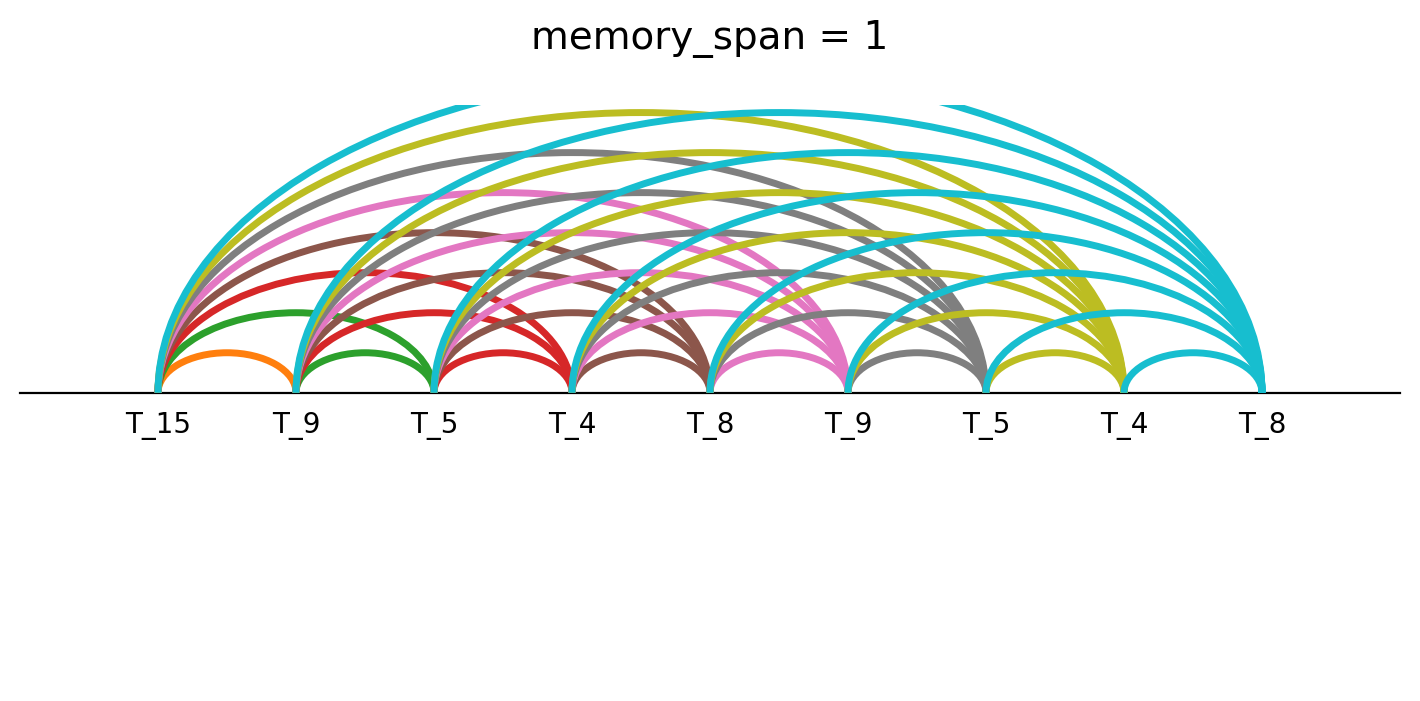

In [6]:
# Simple 2D Attention Mask (without num_heads dimension)
# ======================================================

import torch
from sorl.stat import plot_attn_arcs, materialize_attention_mask, AttentionMaskVisualizer

# Your existing variables
tokens, loss_mask = loader.get_batch(1)
with torch.no_grad(): 
    search_tokens, search_ppt, search_adv = sorl_search(tokens, model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperature,
                                                            truncate_seq_len=False)

# Generate 2D attention mask
levels = (search_tokens >= model.vocab_sizes[0]).long()
attn_mask = materialize_attention_mask(search_tokens, model, memory_span, attn_blocksize=1792)
visualizer = AttentionMaskVisualizer(search_tokens, model, attn_mask)

visualizer.plot_arcs(title="memory_span = 1")


In [7]:
from sorl.eval import compute_vocab_utilization_rate

def eval_cp(model, tokens, K, max_iterations, memory_span, seq_len, loader, temperature=0.0, num_samples=100):
    n_correct = 0
    abs_idx = []
    for _ in range(num_samples): 
        tokens, loss_mask = loader.get_batch(1)
        idx = tokens[:, :1 + seq_len].clone()
        for i in range(seq_len): 
            idx = generate(model, idx, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=1792, temperature=temperature)
            idx_without_abstraction = idx[idx < model.vocab_sizes[0]]
            abs_idx.append(idx[idx >= model.vocab_sizes[0]])
        correct_cp = torch.allclose(idx_without_abstraction[1 : 1 + seq_len], idx_without_abstraction[1 + seq_len : 2 + 2*seq_len])
        n_correct += correct_cp
    acc = n_correct / num_samples
    print(f"=== Copy & Paste Evaluation ===\n Copy correct: {acc * 100:.2f}%")

    data = torch.cat(abs_idx, dim=0)
    abs_util_rate = compute_vocab_utilization_rate(data, model)
    return acc, abs_util_rate


eval_cp(model, tokens, K, max_iterations, memory_span, seq_len, loader, num_samples=50)

=== Copy & Paste Evaluation ===
 Copy correct: 100.00%
 Total abs tokens: 6 | Unique abs tokens: 0 | Abs util rate: 0.00%


(1.0, 0.0)

In [2]:
# heuristic rollout
import os, glob, itertools
from pathlib import Path

# MPS specific data loader functional (single device ver.)
# --------------------------------------------
def _load_data_shard(file: Path):
    header = torch.from_file(str(file), False, 256, dtype=torch.int32) # header is 256 int32
    assert header[0] == 20240520, "magic number mismatch in the data .bin file"
    assert header[1] == 1, "unsupported version"
    num_tokens = int(header[2]) # number of tokens (claimed)
    with file.open("rb", buffering=0) as f:
        tokens = torch.empty(num_tokens, dtype=torch.uint16, pin_memory=False) # MPS requires pin_memory=False
        f.seek(256 * 4)
        nbytes = f.readinto(tokens.numpy()) # avoid bytes->array copy by @YouJiacheng
        assert nbytes == 2 * num_tokens, "number of tokens read does not match header"
    return tokens

def data_generator(filename_pattern: str, sequence_length: int, device: str): 

    filename_pattern = "data/fineweb10B/fineweb_train_*.bin"
    files = [Path(file) for file in sorted(glob.glob(filename_pattern))]
    file_iter = itertools.cycle(files)
    tokens, pos = _load_data_shard(next(file_iter)), 0
    while True: 
        # Concern 1. Doesn't this means end-of-file is never reached?
        if pos + sequence_length + 1 >= len(tokens): # not enough data left -> load a new file
            tokens, pos = _load_data_shard(next(file_iter)), 0

        idx = tokens[pos : pos + sequence_length + 1].unsqueeze(0).to(device=device, dtype=torch.int32, non_blocking=True)
        pos += sequence_length
        yield idx

# ------------------------------------------------

# Question 1. Should we separate inputs / targets? 
#             That's really asking whether we want to 'reflect' on inputs, or inputs + next token
#             from the generation perspective, we ought to reflect on inputs and predict next-tok

# Reflection 1. 
# - based on above thought, we ought to modify the 'forward' method to take 'inputs' & 'targets' separately
#   the ._forward_pass and recursion should be done only on 'inputs'


data = _load_data_shard(Path("data/fineweb10B/fineweb_train_000002.bin"))

train_loader = data_generator(filename_pattern="data/fineweb10B/fineweb_train_*.bin", sequence_length=256, device="cpu")
val_loader = data_generator(filename_pattern="data/fineweb10B/fineweb_val_000000.bin", sequence_length=256, device="cpu")

In [ ]:
# --- Benchmark Speed & Memory Cost --- 
from sorl.benchmark import run_benchmark_suite
import torch 


# Prepare data - TEST WITH SMALLER SEQUENCE FIRST
tokens = next(train_loader)

# Run benchmark
results = run_benchmark_suite(
    model, 
    tokens, 
    memory_span=1024, 
    num_runs=10
)